# **A2D2 Unmasking + Insertion Quality Inference on a Toy Example**

This notebook is a self-contained, runnable illustration of the two quantities at the heart of **A2D2: Fine-Tuning Any-Length Discrete Diffusion for Adaptive Decoding**, and how they are used at *inference* time to decode adaptively:

| Quantity | Definition | Inference use |
|---|---|---|
| **Unmasking quality** $\mu_\star^\ell(\boldsymbol{y})=p(\boldsymbol{y}^\ell=\boldsymbol{x}_1^{s_t[\ell]}\mid \boldsymbol{y})=f_\theta(\tilde{\boldsymbol{x}}_t,t)[\ell,\boldsymbol{x}_1^\ell]$ | probability an unmasked token matches the true token given context | **re-mask** low-quality tokens so only mutually high-quality tokens stay unmasked in parallel |
| **Insertion quality** $\nu_\star^\ell(\boldsymbol{y})=\sum_{\boldsymbol{v}\in\mathcal{S}_\ell}p(\boldsymbol{y}^\ell=\boldsymbol{v}\mid \boldsymbol{y})$ | probability an inserted mask decodes to *some* true token belonging in its gap | **drop** low-quality insertions that would otherwise cause length/spacing errors |

In this notebook, we build a tiny, fully-analytic **toy "language"** whose true denoising posterior $f_\theta$ is known in closed form. That lets us (1) compute $\mu_\star,\nu_\star$ exactly, (2) train the light-weight predictors $\mu_\phi,\nu_\phi$ with the paper's **UQL/IQL** BCE losses and watch them recover the truth, and (3) drive the **actual** A2D2 inference routines `apply_schedule_aware_remasking` / `apply_schedule_aware_insertion` (from `remasking_scheduleaware.py`) on hand-crafted states.

## 0. Setup

The two schedule-aware routines below are from the repo's `remasking_scheduleaware.py`. They are the exact code the A2D2 sampler calls. We only feed them a tiny toy `model` exposing the same interface (`model.planner(seq, t)` → confidences, `model.interpolant.{unmask,insertion}_schedule.at(t)`).

In [15]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

In [ ]:
def _debias_by_token(conf, tokens, clean_index):
    """Subtract the per-token-identity mean confidence so a token's score reflects
    how confident it is RELATIVE to others of the same type (see repo docstring)."""
    if clean_index.sum() == 0:
        return conf
    V = int(tokens.max().item()) + 1
    flat_tok = tokens[clean_index]
    flat_conf = conf[clean_index]
    sums = torch.zeros(V, device=conf.device, dtype=conf.dtype).scatter_add_(0, flat_tok, flat_conf)
    cnts = torch.zeros(V, device=conf.device, dtype=conf.dtype).scatter_add_(
        0, flat_tok, torch.ones_like(flat_conf))
    mean_v = sums / cnts.clamp(min=1.0)
    baseline = mean_v[tokens]
    return torch.where(clean_index, conf - baseline, conf)


def apply_schedule_aware_insertion(model, xt_tmp, new_xt, t, dt, ext, mask, pad,
                                   max_length, orig_mask, new_pos_orig, quality_threshold=1):
    """Remove low-quality insertions (insertion_conf < threshold) while keeping the
    sequence length no shorter than the interpolant schedule allows."""
    device = xt_tmp.device
    batch_size, L = xt_tmp.shape
    total_ext = ext.sum(dim=1)
    if total_ext.sum() == 0:
        return xt_tmp

    t_next = t + dt
    planner_out = model.planner(xt_tmp, t)
    insertion_conf = planner_out.get("insertion_conf", None)
    if insertion_conf is None:
        return xt_tmp
    insertion_conf = insertion_conf.squeeze(-1)  # (B, L)

    current_length_after = xt_tmp.ne(pad).sum(dim=1).float()
    expected_progress = model.interpolant.insertion_schedule.at(t_next)
    estimated_final_length = current_length_after / (expected_progress.clamp(min=0.1))
    expected_length = estimated_final_length * expected_progress

    valid_b, valid_l = orig_mask.nonzero(as_tuple=True)
    valid_p = new_pos_orig[valid_b, valid_l].long().clamp_(0, L - 1)
    is_original = torch.zeros_like(xt_tmp, dtype=torch.bool)
    is_original[valid_b, valid_p] = True
    inserted_positions = (xt_tmp == mask) & ~is_original

    candidates = inserted_positions & (insertion_conf < quality_threshold)
    num_bad = candidates.sum(dim=1)
    min_length = expected_length.long().clamp(min=1)
    max_removable = (current_length_after.long() - min_length).clamp(min=0)
    length_after_removal = current_length_after.long() - num_bad
    schedule_violates = length_after_removal < min_length
    k_per_row = torch.where(schedule_violates, max_removable, num_bad)
    k_per_row = torch.where(num_bad > 0, k_per_row, torch.zeros_like(k_per_row))

    if not candidates.any():
        return xt_tmp

    neg_inf = torch.tensor(float('-inf'), device=device, dtype=insertion_conf.dtype)
    scores = torch.where(candidates, -insertion_conf, neg_inf)
    _, sorted_indices = scores.sort(dim=1, descending=True)
    positions = torch.arange(L, device=device).unsqueeze(0)
    keep_in_topk = positions < k_per_row.unsqueeze(1)
    final_bad = torch.zeros_like(candidates)
    final_bad.scatter_(1, sorted_indices, keep_in_topk)
    if not final_bad.any():
        return xt_tmp

    sort_key = final_bad.long()
    _, perm = torch.sort(sort_key, dim=1, stable=True)
    xt_tmp = torch.gather(xt_tmp, 1, perm)
    num_keep = (~final_bad).sum(dim=1)
    tail_mask = positions >= num_keep.unsqueeze(1)
    xt_tmp = torch.where(tail_mask, torch.full_like(xt_tmp, pad), xt_tmp)
    return xt_tmp


def apply_schedule_aware_remasking(model, new_xt, t, dt, remasking_conf, clean_index,
                                   mask, neg_inf, batch_size, debias=False):
    """Re-mask the lowest-confidence clean tokens so the unmasked count tracks the
    unmask schedule (FlexMDM-style schedule-aware remasking)."""
    t_next = t + dt
    num_clean = clean_index.sum(dim=1)
    current_seq_len = (num_clean + (new_xt == mask).sum(dim=1)).float()
    expected_unmasked_frac = model.interpolant.unmask_schedule.at(t_next)
    expected_num_clean = expected_unmasked_frac * current_seq_len
    masks_to_add = (num_clean.float() - expected_num_clean).round().long()

    k_per_row = torch.minimum(masks_to_add.clamp(min=0), num_clean)
    if k_per_row.sum() == 0:
        return new_xt

    conf = _debias_by_token(remasking_conf, new_xt, clean_index) if debias else remasking_conf
    remasking_score_temp = -1.0 * conf
    remasking_score_temp = torch.where(clean_index, remasking_score_temp, neg_inf)
    _, sorted_indices = remasking_score_temp.sort(dim=1, descending=True)
    L = remasking_score_temp.shape[1]
    positions = torch.arange(L, device=new_xt.device).unsqueeze(0)
    keep_in_topk = positions < k_per_row.unsqueeze(1)
    to_mask = torch.zeros_like(clean_index)
    to_mask.scatter_(1, sorted_indices, keep_in_topk)
    new_xt = torch.where(to_mask, torch.full_like(new_xt, mask), new_xt)
    return new_xt

print("vendored A2D2 schedule-aware routines loaded")

vendored A2D2 schedule-aware routines loaded


## 1. A toy "language" with a known denoising posterior $f_\theta$

A real any-length MDM parameterizes an **unmasking posterior** $f_\theta(\boldsymbol{x}_t,t)[\ell]\in\Delta^V$. Here we replace it with an analytic stand-in: a 5-letter **bigram** model with a peaked transition matrix $T$. Given a partially-masked sequence, the posterior at a masked position is the (normalized) product of the constraints from its clean left/right neighbours, which is exactly the kind of context-dependent posterior $f_\theta$ learns, but in closed form so we know $\mu_\star,\nu_\star$ exactly.

Special tokens: `MASK` and `PAD` (matching the sampler's two reserved ids).

In [17]:
LETTERS = ["A", "B", "C", "D", "E"]
V = len(LETTERS)
MASK, PAD = V, V + 1          # reserved ids, as in the sampler
NTOK = V + 2

# Peaked bigram transition matrix -> context is informative.
T = np.array([
    [0.05, 0.70, 0.10, 0.10, 0.05],   # A -> mostly B
    [0.05, 0.05, 0.75, 0.10, 0.05],   # B -> mostly C
    [0.10, 0.05, 0.05, 0.70, 0.10],   # C -> mostly D
    [0.10, 0.10, 0.05, 0.05, 0.70],   # D -> mostly E
    [0.70, 0.05, 0.10, 0.10, 0.05],   # E -> mostly A
], dtype=np.float64)
T /= T.sum(1, keepdims=True)
pi0 = np.array([0.4, 0.2, 0.2, 0.1, 0.1])     # initial-token distribution

def sample_seq(n):
    """Draw a clean sequence x_1 ~ p_target from the bigram chain."""
    s = [np.random.choice(V, p=pi0)]
    for _ in range(n - 1):
        s.append(np.random.choice(V, p=T[s[-1]]))
    return s

def posterior_at(seq, ell):
    """Toy f_theta(seq, t)[ell] in Delta^V: bigram constraints from clean neighbours."""
    factor = np.ones(V)
    if ell - 1 >= 0 and seq[ell - 1] < V:        # clean left neighbour a -> T[a, :]
        factor *= T[seq[ell - 1], :]
    if ell + 1 < len(seq) and seq[ell + 1] < V:  # clean right neighbour c -> T[:, c]
        factor *= T[:, seq[ell + 1]]
    if factor.sum() == 0:
        factor = np.ones(V)
    return factor / factor.sum()

def decode(seq):
    return "".join("_" if t == MASK else ("." if t == PAD else LETTERS[t]) for t in seq)

x1 = sample_seq(10)
print("a clean target  x1 :", decode(x1))
print("posterior at a masked middle position (neighbours clean):")
probe = x1.copy(); probe[5] = MASK
print("   state:", decode(probe), "   f_theta[5] =", np.round(posterior_at(probe, 5), 3))

a clean target  x1 : BCDEABCDEA
posterior at a masked middle position (neighbours clean):
   state: BCDEA_CDEA    f_theta[5] = [0.009 0.963 0.009 0.009 0.009]


## 2. Unmasking quality $\mu_\star$

Given a clean target $\boldsymbol{x}_1$, an interpolant sample $\tilde{\boldsymbol{x}}_t$ (partially masked), and a candidate unmasking $\boldsymbol{y}$ with $\boldsymbol{y}^\ell \sim f_\theta(\tilde{\boldsymbol{x}}_t,t)[\ell]$, the **unmasking quality** is the posterior probability of the *true* token:

$$\mu_\star^\ell(\boldsymbol{y}) = p\!\left(\boldsymbol{y}^\ell=\boldsymbol{x}_1^{s_t[\ell]}\mid \boldsymbol{y}\right)=f_\theta(\tilde{\boldsymbol{x}}_t,t)[\ell,\boldsymbol{x}_1^\ell]$$

High when the context pins down the token; low when it doesn't. Below, the middle masked position (both neighbours clean) is high-quality, while an isolated masked position (no clean neighbours) has a near-uniform posterior → low quality.

In [18]:
x1 = sample_seq(8)
xt = x1.copy()
for ell in [1, 4, 6]:
    xt[ell] = MASK
print("clean   x1 :", decode(x1))
print("masked  x~t:", decode(xt))
print("masked  isolated: ", end="")
iso = [MASK if i in (0, 1, 2) else x1[i] for i in range(len(x1))]   # left token has no clean nbrs
print(decode(iso))
print()
for ell in [1, 4, 6]:
    p = posterior_at(xt, ell)
    print(f"  pos {ell}: true {LETTERS[x1[ell]]}  mu* = {p[x1[ell]]:.3f}   posterior={np.round(p,2)}")
p_iso = posterior_at(iso, 1)
print(f"  isolated pos 1: true {LETTERS[x1[1]]}  mu* = {p_iso[x1[1]]:.3f}  (near-uniform -> low quality)")

clean   x1 : CDEDABAC
masked  x~t: C_ED_B_C
masked  isolated: ___DABAC

  pos 1: true D  mu* = 0.966   posterior=[0.01 0.   0.01 0.97 0.01]
  pos 4: true A  mu* = 0.596   posterior=[0.6  0.04 0.02 0.04 0.3 ]
  pos 6: true A  mu* = 0.056   posterior=[0.06 0.42 0.42 0.06 0.06]
  isolated pos 1: true D  mu* = 0.200  (near-uniform -> low quality)


### 2.1 Training the unmasking-quality predictor $\mu_\phi$ (UQL)

At inference we have no $\boldsymbol{x}_1$, so A2D2 trains a light head $\mu_\phi$ to predict quality from the *post-unmasking* sequence $\boldsymbol{y}$ alone, via the **Unmasking Quality Loss** (binary cross-entropy against the 0/1 hit indicator):

$$\mathcal{L}_{\text{UQL}}(\phi)=\mathbb{E}\Big[\textstyle\sum_{\ell\in\mathcal{M}}\text{BCE}\big(\mathbf{1}[\boldsymbol{y}^\ell=\boldsymbol{x}_1^{s_t[\ell]}],\,\mu_\phi^\ell(\boldsymbol{y})\big)\Big].$$

The unique minimizer is the true quality: $\mu_{\phi^\star}=\mu_\star$. Note the head sees the *still-masked* neighbours (the realistic decode state), so the BCE minimizer is $P(\text{correct}\mid \boldsymbol{y}) = f_\theta(\cdot)[\ell,\boldsymbol{y}^\ell]$. We verify $\mu_\phi$ recovers it.

In [ ]:
WIN = 2   # context window (each side) fed to the head

def window_feat(seq, ell):
    feats = []
    for d in range(-WIN, WIN + 1):
        j = ell + d
        tok = seq[j] if 0 <= j < len(seq) else PAD
        feats.append(F.one_hot(torch.tensor(tok), NTOK).float())
    return torch.cat(feats)

def make_unmask_example():
    n = np.random.randint(6, 11)
    x1 = sample_seq(n)
    ctx = x1.copy()
    for i in range(n):                       # interpolant: mask ~half the tokens
        if np.random.rand() < 0.5:
            ctx[i] = MASK
    ell = np.random.randint(n)
    p = posterior_at(ctx, ell)
    samp = int(np.random.choice(V, p=p))     # y^ell ~ f_theta(ctx)[ell]
    y = ctx.copy(); y[ell] = samp            # predictor sees still-masked neighbours
    label = float(samp == x1[ell])           # 1[y^ell == x_1]
    return window_feat(y, ell), torch.tensor([label]), p[samp]   # p[samp] = true quality of y

class QualityHead(nn.Module):
    def __init__(self, din):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(din, 64), nn.GELU(), nn.Linear(64, 1))
    def forward(self, x):
        return torch.sigmoid(self.net(x))
    
din = (2 * WIN + 1) * NTOK

"""
The UQL label 1[y^l == x_1] is a coin flip with probability mu_star, so even a PERFECT
mu_phi cannot beat the entropy floor E[H(mu_star)]. The per-batch loss is also noisy
(a fresh random minibatch each step), so we report an EMA-smoothed running loss + the floor. 

Convergence means the running loss sits AT the floor, not that it reaches 0
""" 
_, _, q_pool = zip(*[make_unmask_example() for _ in range(4000)])
uql_floor = binary_entropy(q_pool)

mu_phi = QualityHead(din)
opt = torch.optim.Adam(mu_phi.parameters(), lr=2e-3)
run = None
for step in range(2000):
    feats, labels, _ = zip(*[make_unmask_example() for _ in range(64)])
    loss = F.binary_cross_entropy(mu_phi(torch.stack(feats)), torch.stack(labels))
    opt.zero_grad(); loss.backward(); opt.step()
    run = loss.item() if run is None else 0.98 * run + 0.02 * loss.item()
    if (step + 1) % 500 == 0:
        print(f"  step {step+1:4d}   UQL running avg = {run:.4f}")

with torch.no_grad():
    fs, _, qs = zip(*[make_unmask_example() for _ in range(800)])
    pred = mu_phi(torch.stack(fs)).squeeze(-1).numpy()
qs = np.array(qs)
print(f"corr(mu_phi, mu_star) on held-out states = {np.corrcoef(pred, qs)[0,1]:.3f}")

  step  500   UQL running avg = 0.5410   (irreducible floor = 0.4777)
  step 1000   UQL running avg = 0.4752   (irreducible floor = 0.4777)
  step 1500   UQL running avg = 0.4573   (irreducible floor = 0.4777)
  step 2000   UQL running avg = 0.4625   (irreducible floor = 0.4777)

running loss 0.4625 sits at the floor 0.4777  ->  converged
corr(mu_phi, mu_star) on held-out states = 0.959


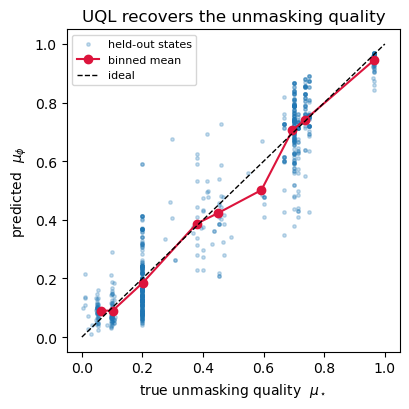

In [ ]:
# predicted quality vs. true quality mu_star
plt.figure(figsize=(4.2, 4.2))
plt.scatter(qs, pred, s=6, alpha=0.25, label="held-out states")
bins = np.linspace(0, 1, 11)
idx = np.digitize(qs, bins) - 1
bx = [qs[idx == b].mean() for b in range(10) if (idx == b).any()]
by = [pred[idx == b].mean() for b in range(10) if (idx == b).any()]
plt.plot(bx, by, "o-", color="crimson", label="binned mean")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="ideal")
plt.xlabel(r"true unmasking quality  $\mu_\star$")
plt.ylabel(r"predicted  $\mu_\phi$")
plt.title("UQL recovers the unmasking quality")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## 3. Insertion quality $\nu_\star$

When the model inserts a mask into the gap between surviving tokens $\ell-1$ and $\ell$,
its **insertion quality** is the probability that the mask decodes to *some* token that
genuinely belongs in that gap, $\mathcal{S}_\ell=\{\boldsymbol{x}_1^i: s_t[\ell-1]<i<s_t[\ell]\}$:

$$\nu_\star^\ell(\boldsymbol{y})=\sum_{\boldsymbol{v}\in\mathcal{S}_\ell}p(\boldsymbol{y}^\ell=\boldsymbol{v}\mid \boldsymbol{y})=p(\boldsymbol{y}^\ell\in\mathcal{S}_\ell\mid \boldsymbol{y}).$$

Crucially, when **no** token belongs between the neighbours ($\mathcal{S}_\ell=\varnothing$),
the quality is **0**, and the insertion should be dropped.

In [21]:
def insertion_quality(x1, lo, hi):
    """Mask inserted between clean tokens at indices lo and hi of x1.
    S_ell = the true tokens strictly between them; nu_star = posterior mass on S_ell."""
    gap = [x1[i] for i in range(lo + 1, hi)]
    left = x1[lo]
    right = x1[hi] if hi < len(x1) else PAD
    y = [left, MASK, right]
    p = posterior_at(y, 1)
    nu = float(sum(p[v] for v in set(gap)))
    return nu, gap, p

x1 = sample_seq(8)
print("clean x1:", decode(x1))
nu_real, gap_real, _ = insertion_quality(x1, 2, 4)   # gap holds the real token at index 3
print(f"  insert into a REAL gap (true {LETTERS[x1[3]]} belongs here): nu* = {nu_real:.3f}")
nu_empty, gap_empty, _ = insertion_quality(x1, 2, 3)  # neighbours adjacent -> empty gap
print(f"  insert into an EMPTY gap (nothing belongs):                 nu* = {nu_empty:.3f}  gap={gap_empty}")

clean x1: BCDEABDB
  insert into a REAL gap (true E belongs here): nu* = 0.961
  insert into an EMPTY gap (nothing belongs):                 nu* = 0.000  gap=[]


### 3.1 Training the insertion-quality predictor $\nu_\phi$ (IQL)

Similarly, $\nu_\phi$ is trained with the **Insertion Quality Loss**, which is a BCE against the (soft) target $\nu_\star$, taking only the post-insertion sequence $\boldsymbol{y}$ as input:

$$\mathcal{L}_{\text{IQL}}(\phi)=\mathbb{E}\Big[\textstyle\sum_{i\in\mathcal{I}}\text{BCE}\big(\nu_\star^i(\boldsymbol{y}),\,\nu_\phi^i(\boldsymbol{y})\big)\Big],$$

whose unique minimizer is $\nu_\star$. The predictor learns to assign near-zero quality to inserts whose neighbours are already adjacent in the target.

  step  500   IQL running avg = 0.4728   (irreducible floor = 0.2009)
  step 1000   IQL running avg = 0.4763   (irreducible floor = 0.2009)
  step 1500   IQL running avg = 0.4646   (irreducible floor = 0.2009)
  step 2000   IQL running avg = 0.4717   (irreducible floor = 0.2009)

running loss 0.4717 sits at the floor 0.2009  ->  converged
corr(nu_phi, nu_star) = 0.644


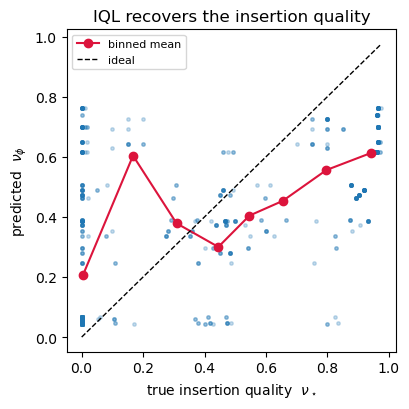

In [22]:
def make_insert_example():
    n = np.random.randint(6, 11)
    x1 = sample_seq(n)
    i = np.random.randint(1, n - 1)
    gapsize = int(np.random.choice([0, 0, 1, 2]))   # often empty -> nu* = 0
    left = x1[i - 1]
    rj = i + gapsize
    right = x1[rj] if rj < n else PAD
    gap = [x1[j] for j in range(i, rj)]
    y = [left, MASK, right]
    p = posterior_at(y, 1)
    nu = float(sum(p[v] for v in set(gap)))
    return window_feat(y, 1), torch.tensor([nu]), nu

# IQL's target nu_star is a *soft* value in [0,1], so BCE(nu_star, nu_phi) bottoms out at E[H(nu_star)] rather than 0
# same idea as UQL, again reported with the floor + EMA

_, _, nu_pool = zip(*[make_insert_example() for _ in range(4000)])
iql_floor = binary_entropy(nu_pool)

nu_phi = QualityHead(din)
opt = torch.optim.Adam(nu_phi.parameters(), lr=2e-3)
run = None
for step in range(2000):
    feats, soft, _ = zip(*[make_insert_example() for _ in range(64)])
    loss = F.binary_cross_entropy(nu_phi(torch.stack(feats)), torch.stack(soft))
    opt.zero_grad(); loss.backward(); opt.step()
    run = loss.item() if run is None else 0.98 * run + 0.02 * loss.item()
    if (step + 1) % 500 == 0:
        print(f"  step {step+1:4d}   IQL running avg = {run:.4f}")

with torch.no_grad():
    fs, _, qs = zip(*[make_insert_example() for _ in range(800)])
    pred = nu_phi(torch.stack(fs)).squeeze(-1).numpy()
qs = np.array(qs)
print(f"corr(nu_phi, nu_star) = {np.corrcoef(pred, qs)[0,1]:.3f}")

plt.figure(figsize=(4.2, 4.2))
plt.scatter(qs, pred, s=6, alpha=0.25)
bins = np.linspace(0, qs.max() + 1e-6, 9)
idx = np.digitize(qs, bins) - 1
bx = [qs[idx == b].mean() for b in range(len(bins)) if (idx == b).any()]
by = [pred[idx == b].mean() for b in range(len(bins)) if (idx == b).any()]
plt.plot(bx, by, "o-", color="crimson", label="binned mean")
lim = max(qs.max(), pred.max())
plt.plot([0, lim], [0, lim], "k--", lw=1, label="ideal")
plt.xlabel(r"true insertion quality  $\nu_\star$")
plt.ylabel(r"predicted  $\nu_\phi$")
plt.title("IQL recovers the insertion quality")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## 4. Quality-guided inference with A2D2

The A2D2 sampler (`_diffusion_loop`) alternates *unmask* and *insert* Euler steps, and after each one calls the two schedule-aware routines we vendored in §0 to **re-mask low-quality tokens** and **drop low-quality insertions**, keeping the masked/clean counts on the interpolant schedule. We exercise the actual functions with a minimal toy model.

The toy example only needs `model.planner(seq, t)` returning per-position confidences, and `model.interpolant.{unmask,insertion}_schedule.at(t)` (linear schedule here).

In [23]:
class LinearSchedule:
    def at(self, t):
        return t.clone() if torch.is_tensor(t) else torch.tensor(float(t))

class ToyInterpolant:
    unmask_schedule = LinearSchedule()
    insertion_schedule = LinearSchedule()

class ToyPlanner:
    """Stand-in for the trained planner. We pass confidences in directly so we can script
    exactly which token / insertion is low-quality; in A2D2 these come from mu_phi / nu_phi."""
    def __init__(self, remask_conf=None, insert_conf=None):
        self.remask_conf, self.insert_conf = remask_conf, insert_conf
    def __call__(self, seq, t):
        B, L = seq.shape
        out = {}
        if self.remask_conf is not None:
            out["remasking_conf"] = self.remask_conf.view(B, L, 1)
        if self.insert_conf is not None:
            out["insertion_conf"] = self.insert_conf.view(B, L, 1)
        return out

class ToyModel:
    def __init__(self, planner):
        self.planner = planner
        self.interpolant = ToyInterpolant()

neg_inf = torch.tensor(-np.inf)

### 4.1 Schedule-aware **re-masking** (low unmasking quality → re-masked)

Four clean tokens `ABCD` and two masks. Position 1 (`B`) is given a low unmasking-quality confidence (0.10) while the rest are confident. With the schedule asking for one more mask at this step, the routine re-masks exactly the lowest-quality token.

In [24]:
new_xt      = torch.tensor([[0, 1, 2, 3, MASK, MASK]])         # ABCD__
conf        = torch.tensor([[0.9, 0.1, 0.95, 0.92, 0.0, 0.0]]) # pos 1 = low quality
clean_index = (new_xt != MASK) & (new_xt != PAD)
model = ToyModel(ToyPlanner())          # remasking_conf is passed in directly
t, dt = torch.tensor([0.4]), 0.1

out = apply_schedule_aware_remasking(model, new_xt.clone(), t, dt, conf, clean_index,
                                     MASK, neg_inf, batch_size=1)
print("before:", decode(new_xt[0].tolist()))
print("after :", decode(out[0].tolist()), "   <- the low-quality 'B' was re-masked")

before: ABCD__
after : A_CD__    <- the low-quality 'B' was re-masked


### 4.2 Schedule-aware **insertion deletion** (low insertion quality → dropped)

State `A_BC_` after inserting two masks (between `A` & `B`, and after `C`). The first inserted mask gets a low insertion-quality confidence (0.05); with `quality_threshold=0.5` the routine drops it and compacts the sequence, keeping the confident insertion.

In [25]:
new_xt = torch.tensor([[0, 1, 2, PAD, PAD, PAD]])  # ABC  (3 clean)
xt_tmp = torch.tensor([[0, MASK, 1, 2, MASK, PAD]]) # A_BC_  after inserts
ext = torch.tensor([[0, 1, 0, 1, 0, 0]]) # 1 insert in gaps 1 and 3
orig_mask = torch.tensor([[True, False, True, True, False, False]])
new_pos_orig = torch.tensor([[0, 2, 3, 3, 4, 5]]) # originals shifted right
insert_conf = torch.tensor([[0.9, 0.05, 0.9, 0.9, 0.95, 0.0]]) # inserted mask @pos1 = low
model = ToyModel(ToyPlanner(insert_conf=insert_conf))
t, dt = torch.tensor([0.0]), 0.05

out = apply_schedule_aware_insertion(model, xt_tmp.clone(), new_xt, t, dt, ext,
                                     MASK, PAD, max_length=6, orig_mask=orig_mask,
                                     new_pos_orig=new_pos_orig, quality_threshold=0.5)

print("before:", decode(xt_tmp[0].tolist()))
print("after :", decode(out[0].tolist()), "   <- low-quality insertion dropped, kept the good one")

before: A_BC_.
after : ABC_..    <- low-quality insertion dropped, kept the good one


## 5. Putting it together: quality inference catches decoding errors

The point of both predictors is to flag mistakes *without* access to $\boldsymbol{x}_1$. Here we corrupt one position of a clean target (decode it to the wrong letter) and let the trained $\mu_\phi$ score every clean token. The corrupted position gets the **lowest** predicted unmasking quality — so A2D2's schedule-aware re-masking would target it for a re-do, exactly as intended.

target  x1: BCDECDEAB
decoded  y: BCDEEDEAB    (position 4 corrupted: C -> E)

 predicted unmasking quality mu_phi per position:
   pos 0 (B): 0.666
   pos 1 (C): 0.948
   pos 2 (D): 0.920
   pos 3 (E): 0.339
   pos 4 (E): 0.041 *corrupted*  <-- lowest, would be re-masked
   pos 5 (D): 0.595
   pos 6 (E): 0.918
   pos 7 (A): 0.957
   pos 8 (B): 0.745


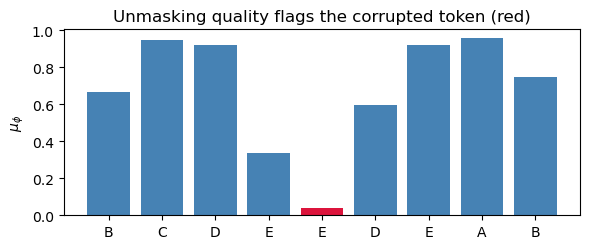

In [26]:
x1 = sample_seq(9)
y = x1.copy()
bad_pos = 4
y[bad_pos] = (x1[bad_pos] + 2) % V          # decode this position to a WRONG letter

with torch.no_grad():
    scores = []
    for ell in range(len(y)):
        scores.append(mu_phi(window_feat(y, ell).unsqueeze(0)).item())

print("target  x1:", decode(x1))
print("decoded  y:", decode(y), f"   (position {bad_pos} corrupted: {LETTERS[x1[bad_pos]]} -> {LETTERS[y[bad_pos]]})")
print("\n predicted unmasking quality mu_phi per position:")
for ell, s in enumerate(scores):
    flag = "  <-- lowest, would be re-masked" if ell == int(np.argmin(scores)) else ""
    star = " *corrupted*" if ell == bad_pos else ""
    print(f"   pos {ell} ({LETTERS[y[ell]]}): {s:.3f}{star}{flag}")

plt.figure(figsize=(6, 2.6))
colors = ["crimson" if ell == bad_pos else "steelblue" for ell in range(len(y))]
plt.bar(range(len(y)), scores, color=colors)
plt.xticks(range(len(y)), [LETTERS[t] for t in y])
plt.ylabel(r"$\mu_\phi$"); plt.title("Unmasking quality flags the corrupted token (red)")
plt.tight_layout(); plt.show()

## Summary

- **Unmasking quality** $\mu_\star$ and **insertion quality** $\nu_\star$ are defined in closed form here from a known posterior; the predictors $\mu_\phi,\nu_\phi$ trained with the paper's **UQL / IQL** BCE losses recover them.
- At inference, A2D2 turns these scores that are used in `apply_schedule_aware_remasking` (re-mask low-quality tokens) and `apply_schedule_aware_insertion` (drop low-quality insertions), both shown here on toy states and tied back to a corrupted-decode example.
- Swap the toy `posterior_at` / `ToyPlanner` for a trained any-length MDM + its planner heads (`model/model_wrapper py::RemaskingAnyOrder`) and this becomes the quality-guided decode used in `a2d2_mol` / `a2d2_pep` / `a2d2_language`.